# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [98]:
from pipeline.CombinedDeconvolveGeneExpressionRunner \
    import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'

runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)


In [99]:
from src.config import load_cloccs_configs
config1, config2 = load_cloccs_configs()

In [219]:
def gene_alpha_search(gene_name, kappa, replicate, alphas=None):

    solutions = []
    print(f"Searching replicate {replicate } alphas: {gene_name}...")

    for alpha in alphas:
        print(alpha, end=",")
        if replicate == 1:
            runner.config1.modify_alpha(alpha)
        elif replicate == 2:
            runner.config2.modify_alpha(alpha)
        find_gamma = runner.deconvolve_gene(gene_name, kappa=kappa,
            replicate=replicate)   
    
        solution = find_gamma.retrieve_solution()
        solutions.append(solution)
    print()

    df = pd.DataFrame(solutions, index=alphas)
    df.index.name = 'alpha'
    df['gene'] = gene_name
    df['replicate'] = replicate
    df = df.reset_index().set_index(['replicate', 'alpha', 'gene'])
    
    return df


In [220]:
from src.timer import Timer
timer = Timer()
alphas = np.arange(4, 49, 2)

gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4',
    'ASH1', 'EGT2', 'AMN1', 'PRY3', 'SCW11', 'CTS1']

solutions = []
for replicate in [1, 2]:
    for gene_name in gene_names:
        solution_result = gene_alpha_search(gene_name, kappa=0.0, 
                                          replicate=replicate, alphas=alphas)
        solutions.append(solution_result)
        timer.print_time()

all_alpha_results_df = pd.concat(solutions)

Searching replicate 1 alphas: DSE1...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:02:22.310
Searching replicate 1 alphas: DSE2...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:04:43.500
Searching replicate 1 alphas: DSE3...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:07:03.050
Searching replicate 1 alphas: DSE4...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:09:20.436
Searching replicate 1 alphas: ASH1...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:11:40.624
Searching replicate 1 alphas: EGT2...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:13:58.871
Searching replicate 1 alphas: AMN1...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:16:19.308
Searching replicate 1 alphas: PRY3...
4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,
00:18:39.107
Searching replicate 1 alphas: SCW11...
4,6,8,10,12,14,16

In [ ]:
runner.expression_find_gamma.plot_gamma_sweep()

In [ ]:
from src.alpha_search import plot_alpha_genes_subplots

In [225]:
all_alpha_results_df

0         1         2         3         4    \
replicate alpha gene                                                     
1         4     DSE1  7.169293  6.434716  5.657280  6.622807  9.436746   
          6     DSE1  6.814995  6.823265  6.781132  6.503426  6.291859   
          8     DSE1  7.637515  7.248234  6.579610  5.826357  5.356351   
          10    DSE1  6.942840  6.933880  6.921876  6.919365  6.866912   
          12    DSE1  7.176700  7.106690  7.018219  6.926845  6.799584   
...                        ...       ...       ...       ...       ...   
2         40    CTS1  9.510089  9.402096  9.288223  9.170645  9.049623   
          42    CTS1  9.472256  9.361221  9.244429  9.124568  9.002121   
          44    CTS1  9.250248  9.186265  9.117148  9.044469  8.968455   
          46    CTS1  9.124381  9.134711  9.140150  9.139371  9.131739   
          48    CTS1  8.530373  8.623086  8.712768  8.797576  8.877074   

                           5          6          7          8          9    \
replicate alpha gene                                                         
1         4     DSE1  9.160839   8.847206   8.491484   9.436746   9.160840   
          6     DSE1  6.846809  10.262986  10.048867   9.796487   9.431524   
          8     DSE1  5.490068   6.021629   6.821606  10.956070  10.647394   
          10    DSE1  6.753428   6.594637   6.280836   6.035453   6.302735   
          12    DSE1  6.614008   6.396675   6.167699   6.027691   6.044077   
...                        ...        ...        ...        ...        ...   
2         40    CTS1  8.925129   8.801032   8.681365   8.569985   8.470665   
          42    CTS1  8.877314   8.754383   8.637607   8.531349   8.439826   
          44    CTS1  8.889137   8.809236   8.731576   8.658916   8.593938   
          46    CTS1  9.116433   9.092991   9.061423   9.020853   8.970570   
          48    CTS1  8.950902   9.016713   9.072306   9.115248   9.143194   

                      ...       151       152       153       154       155  \
replicate alpha gene  ...                                                     
1         4     DSE1  ...       NaN       NaN       NaN       NaN       NaN   
          6     DSE1  ...       NaN       NaN       NaN       NaN       NaN   
          8     DSE1  ...       NaN       NaN       NaN       NaN       NaN   
          10    DSE1  ...       NaN       NaN       NaN       NaN       NaN   
          12    DSE1  ...       NaN       NaN       NaN       NaN       NaN   
...                   ...       ...       ...       ...       ...       ...   
2         40    CTS1  ...       NaN       NaN       NaN       NaN       NaN   
          42    CTS1  ...       NaN       NaN       NaN       NaN       NaN   
          44    CTS1  ...  7.672690  9.250248       NaN       NaN       NaN   
          46    CTS1  ...  7.951125  7.948462  7.942807  7.934271  7.923124   
          48    CTS1  ...  8.126822  8.139566  8.151625  8.160328  8.163252   

                           156       157       158       159       160  
replicate alpha gene                                                    
1         4     DSE1       NaN       NaN       NaN       NaN       NaN  
          6     DSE1       NaN       NaN       NaN       NaN       NaN  
          8     DSE1       NaN       NaN       NaN       NaN       NaN  
          10    DSE1       NaN       NaN       NaN       NaN       NaN  
          12    DSE1       NaN       NaN       NaN       NaN       NaN  
...                        ...       ...       ...       ...       ...  
2         40    CTS1       NaN       NaN       NaN       NaN       NaN  
          42    CTS1       NaN       NaN       NaN       NaN       NaN  
          44    CTS1       NaN       NaN       NaN       NaN       NaN  
          46    CTS1  9.124381       NaN       NaN       NaN       NaN  
          48    CTS1  8.155103  8.130856  8.094696  8.052137  8.530373  

[460 rows x 161 columns]

In [231]:
from src.utils import mkdir_safe
from src.figure_configs import save_figure_for_paper
save_dir = f"{output_directory}/alpha_search"

mkdir_safe(save_dir)

Creating directory: output/prototype_pipeline_subset//alpha_search...Directory exists. Skipping.


Saved figure to: output/prototype_pipeline_subset//alpha_search/alphas_repl1.png


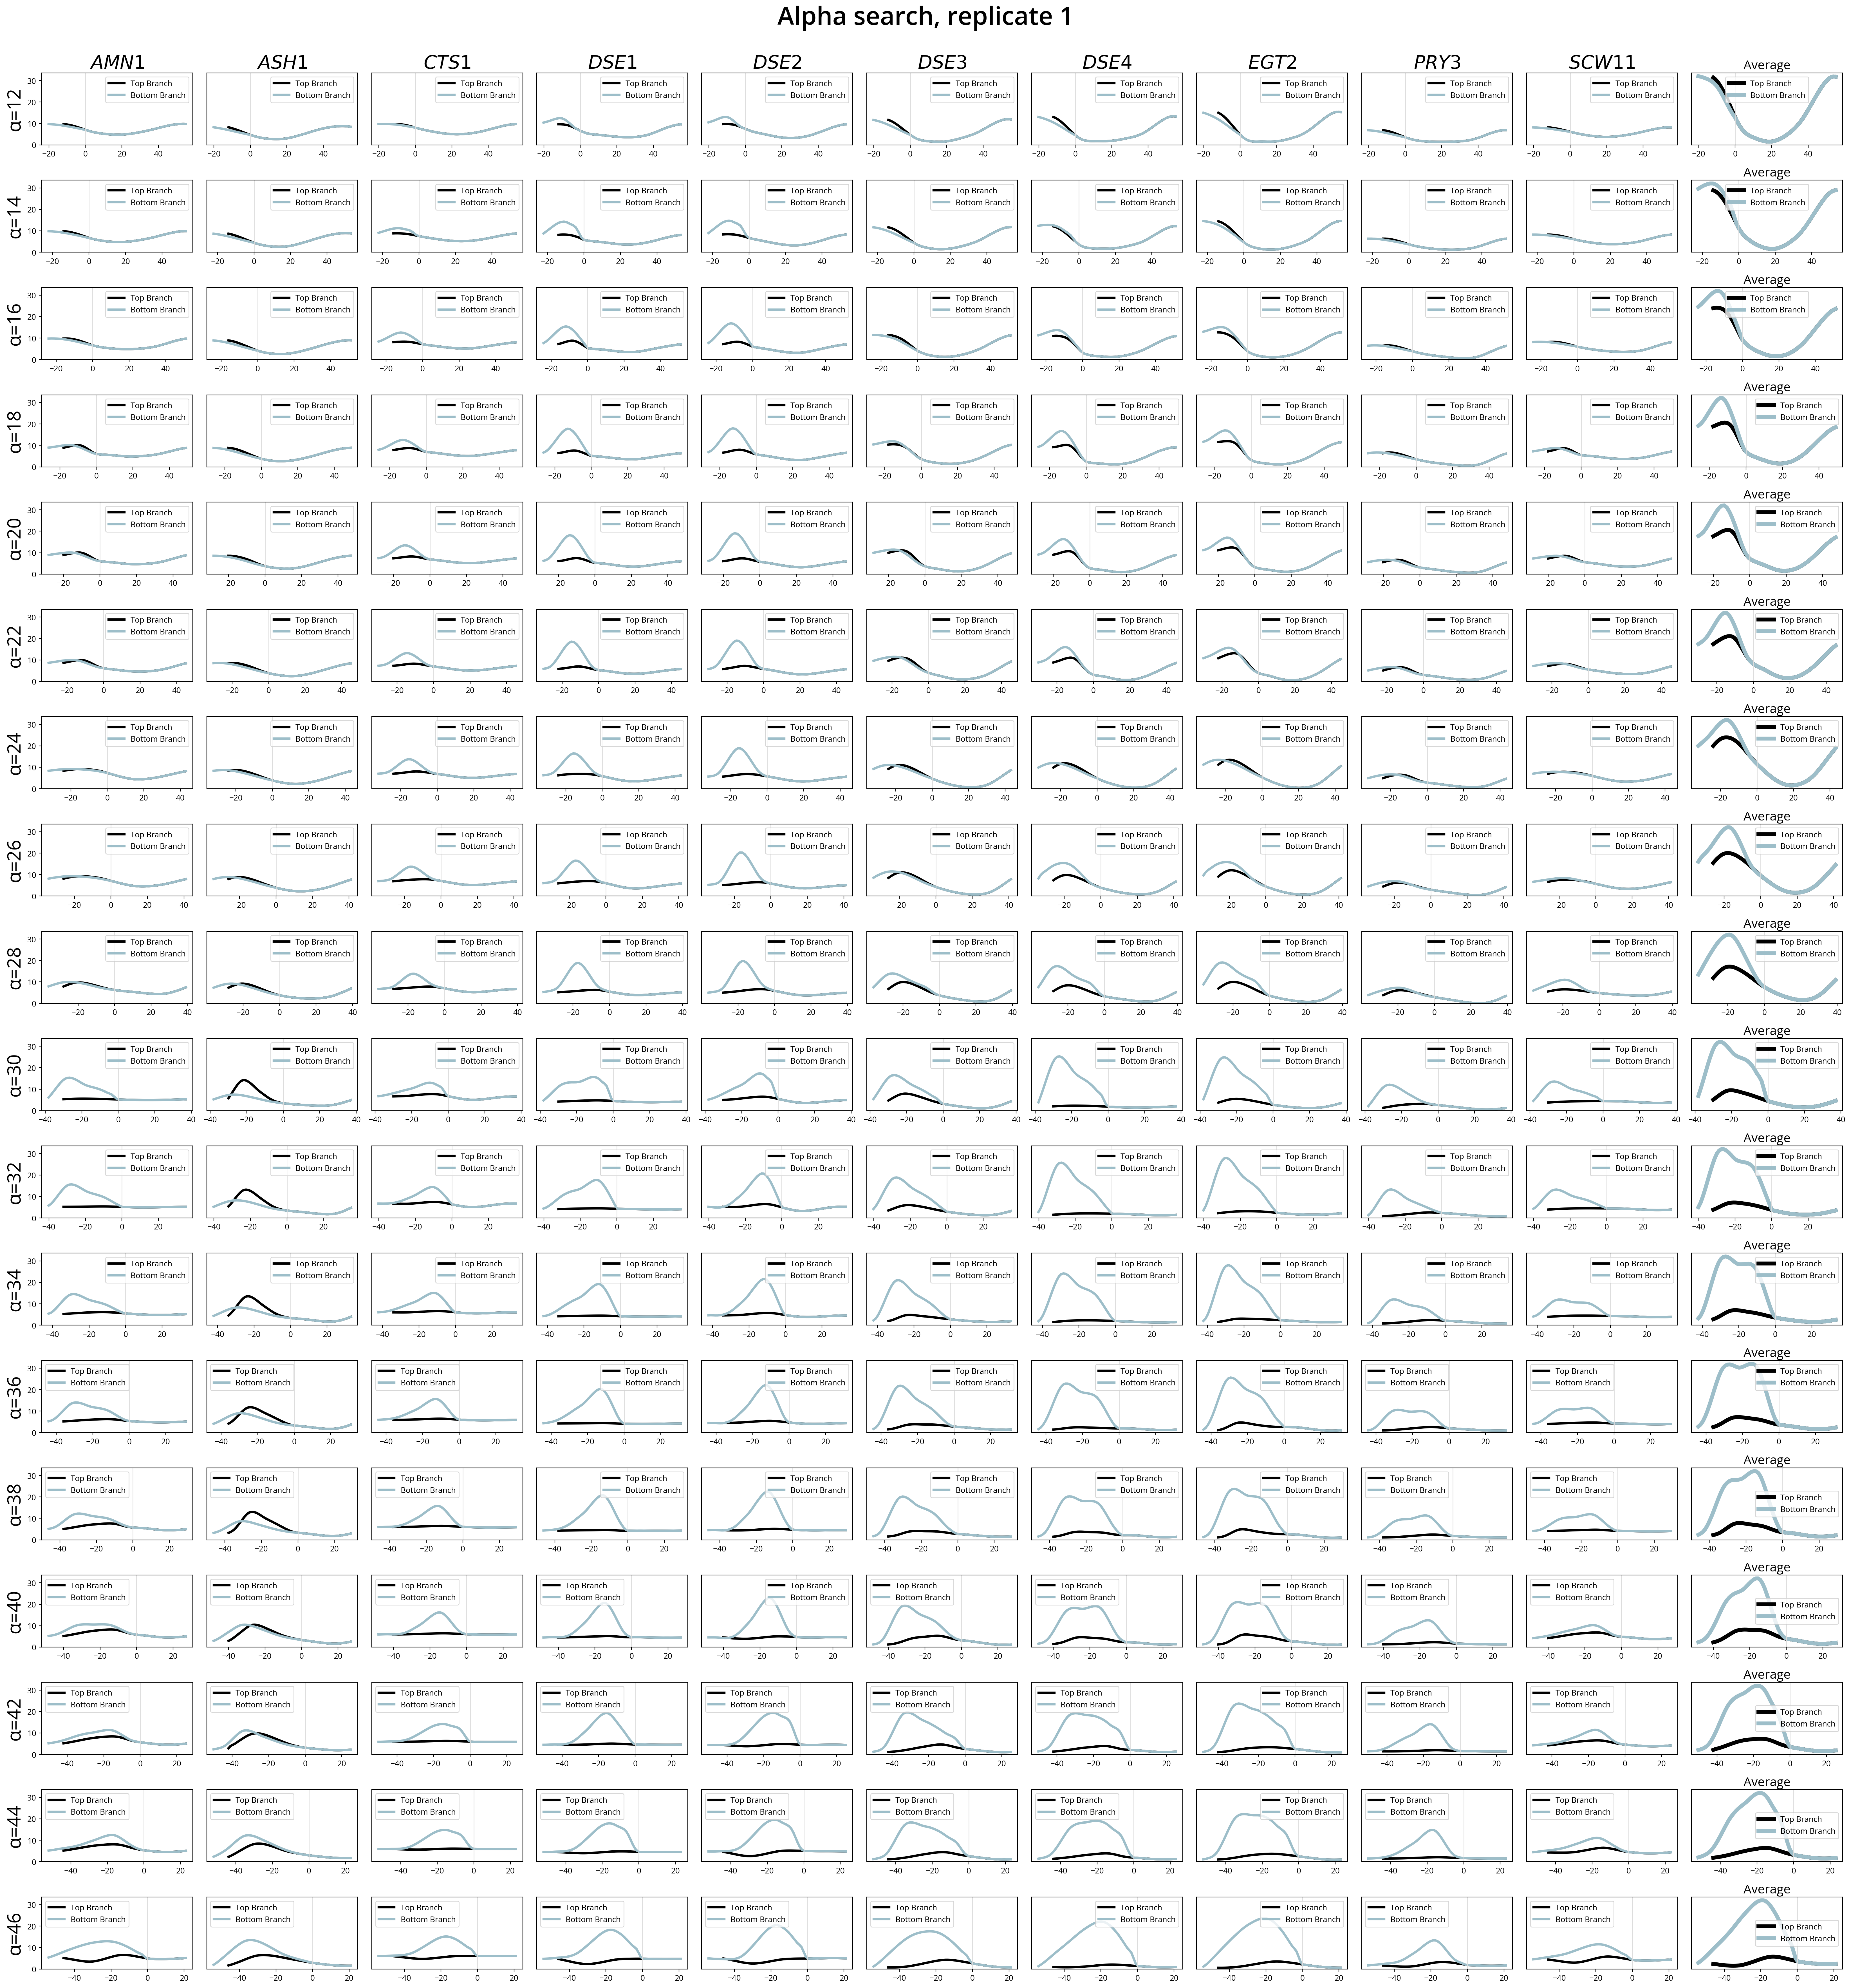

In [252]:
plot_alphas = np.arange(12, 48, 2)
fig = plot_alpha_genes_subplots(config1, plot_alphas, all_alpha_results_df, 1)

all_alpha_results_df.to_csv(f"{save_dir}/alphas_repl1.csv")
save_figure_for_paper(f"{save_dir}/alphas_repl1.png", dpi=80)


Saved figure to: output/prototype_pipeline_subset//alpha_search/alphas_repl2.png


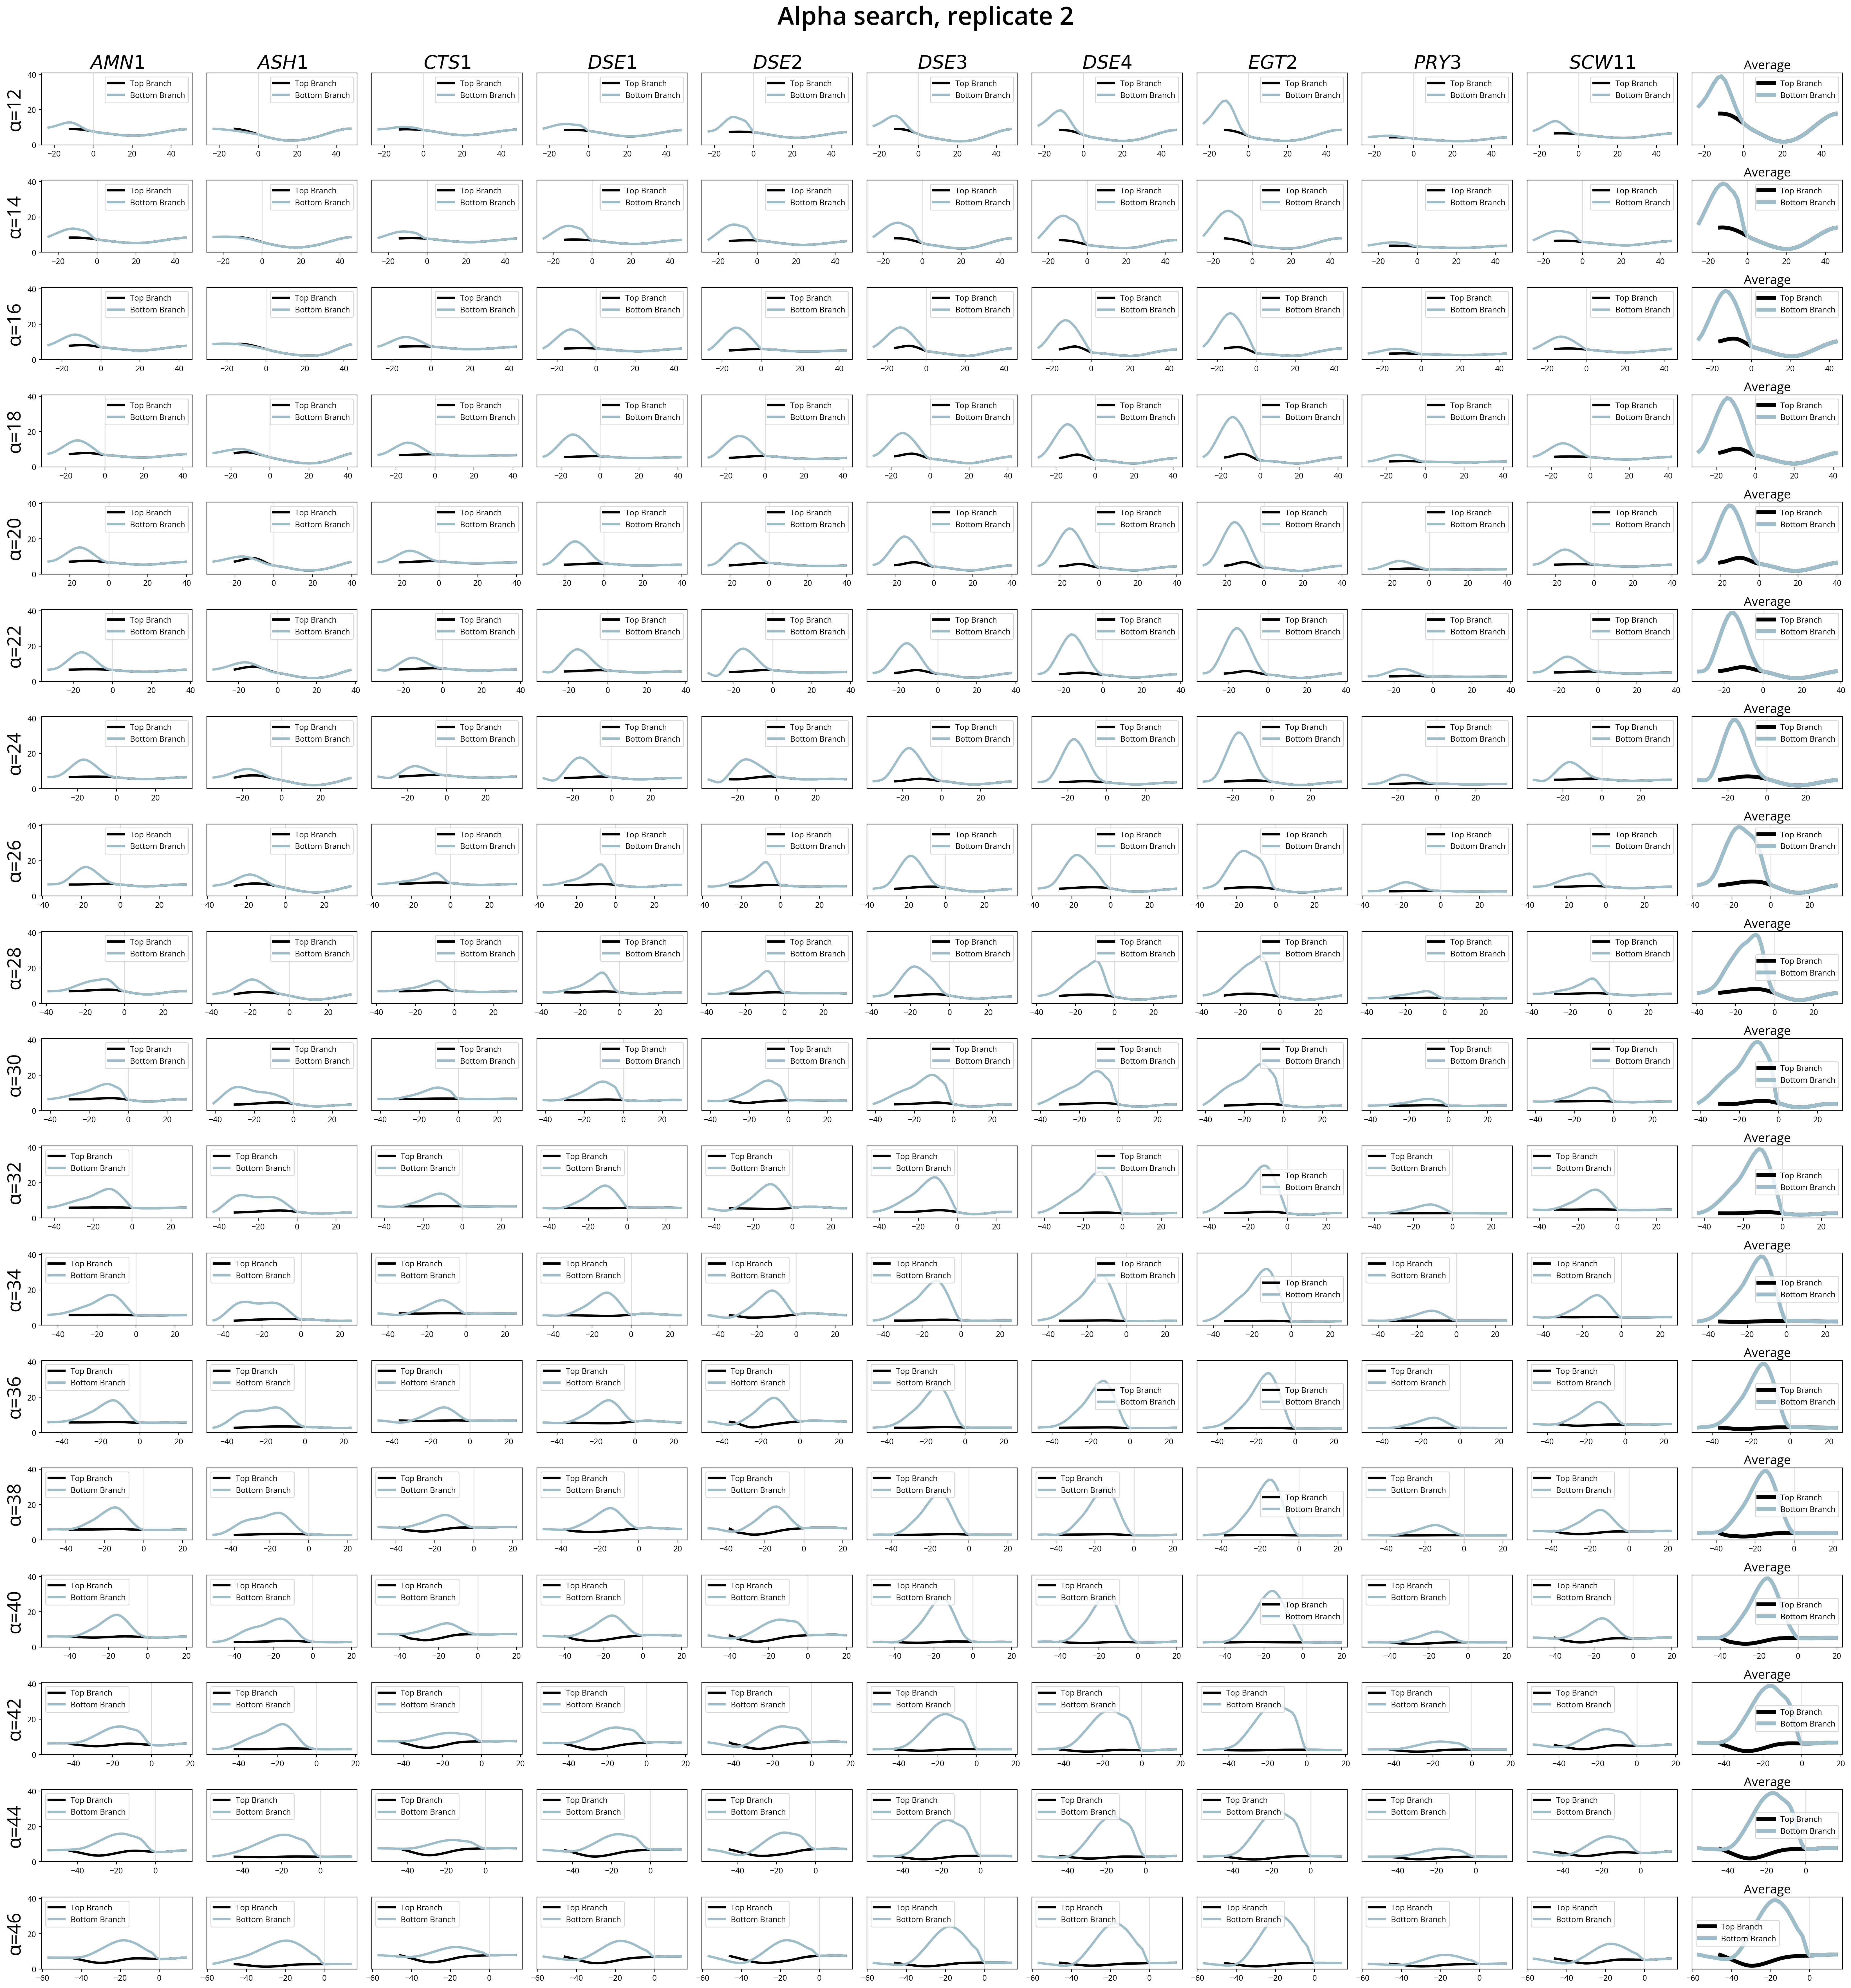

In [253]:
fig = plot_alpha_genes_subplots(config2, plot_alphas, all_alpha_results_df, 2)

all_alpha_results_df.to_csv(f"{save_dir}/alphas_repl2.csv")
save_figure_for_paper(f"{save_dir}/alphas_repl2.png", dpi=80)

In [259]:
runner.config1.modify_alpha(30)

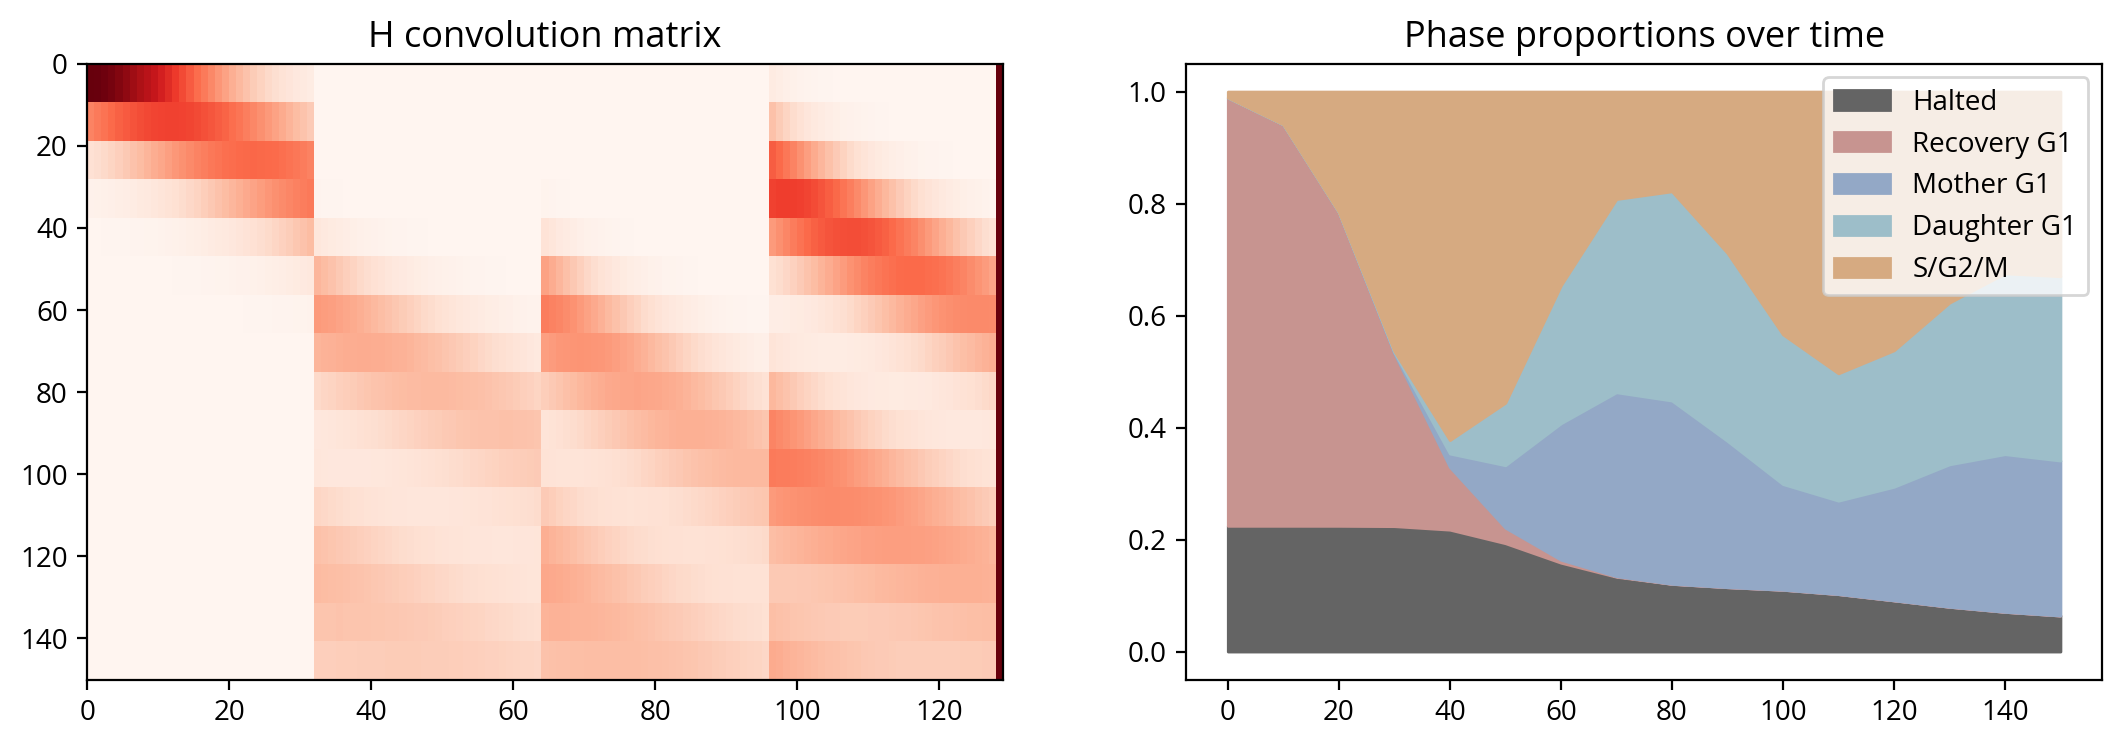

In [264]:
runner.config1.plot_H()

In [574]:
runner.config1.alpha

32

In [526]:
find_gamma = runner.deconvolve_gene('DSE1', kappa=0,
    replicate=1)

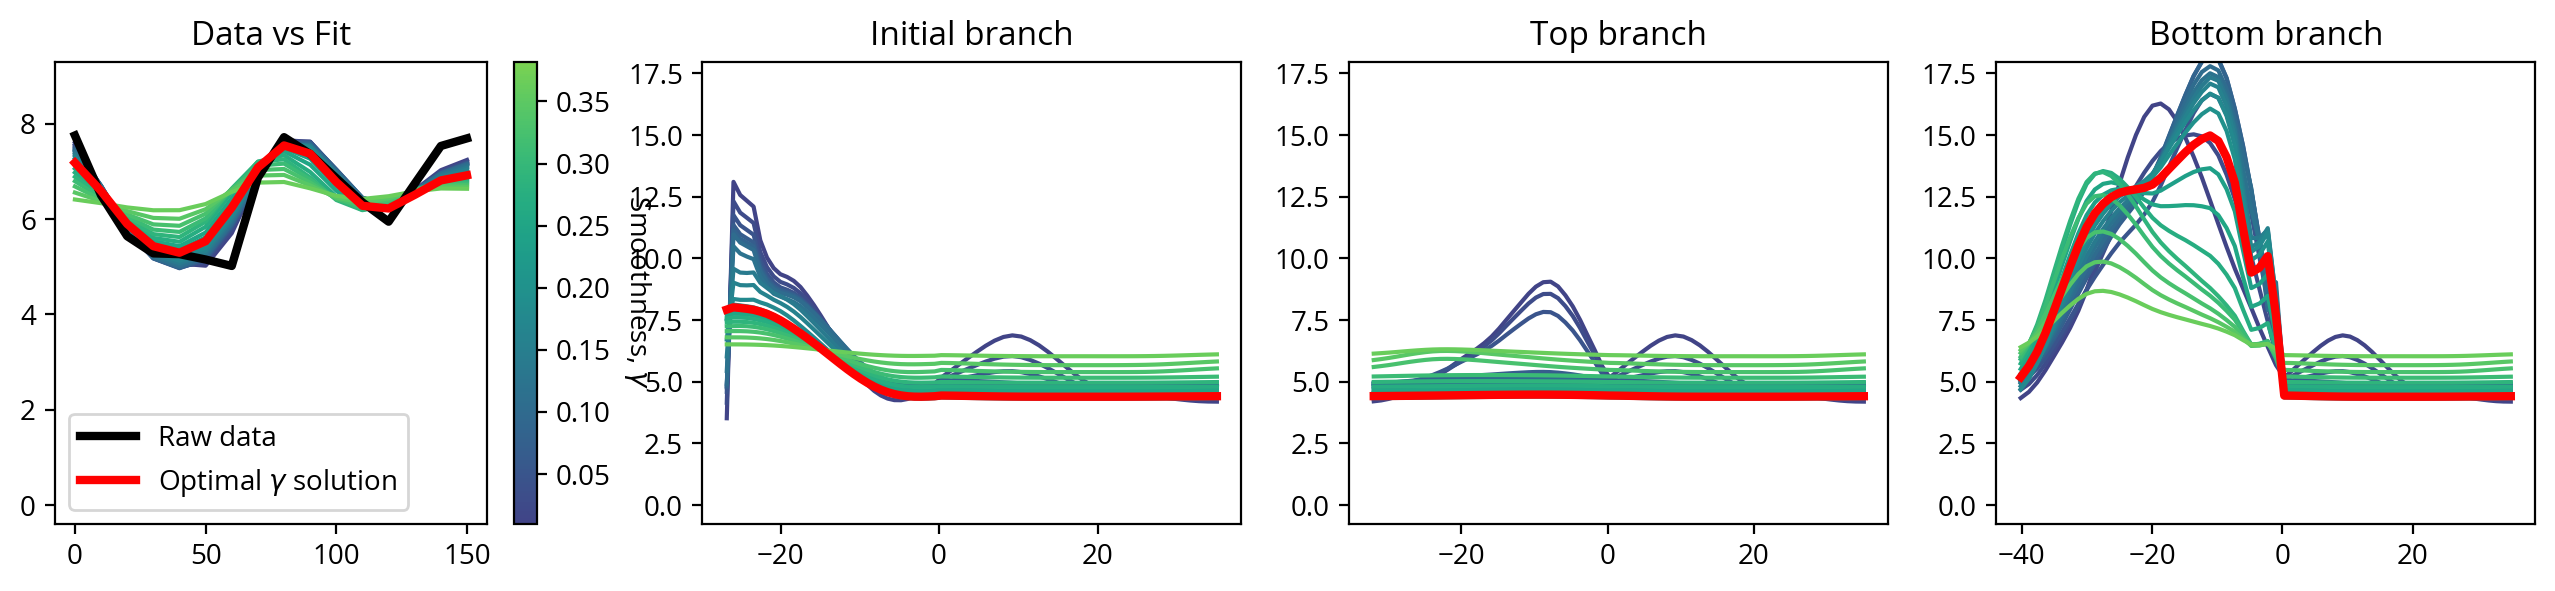

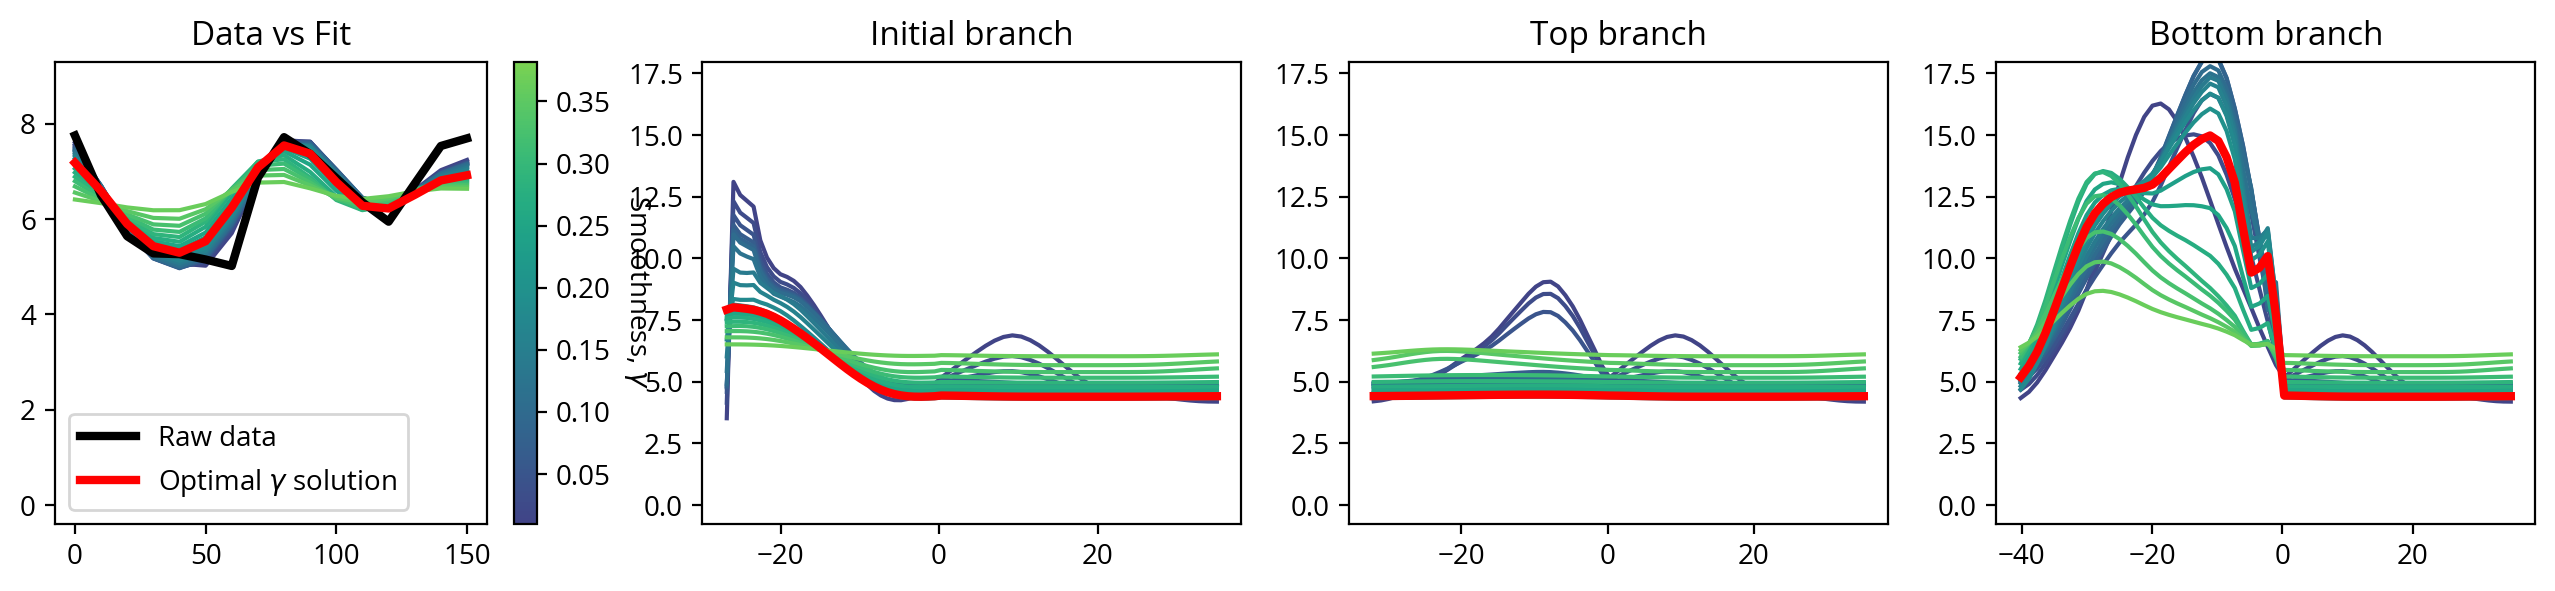

In [527]:
find_gamma.plot_gamma_sweep()

In [525]:
find_gamma.gamma_optimizer.optimal_gamma 

0.08687436524022894

In [596]:
solver = find_gamma.deconvolution_solver
solver.gamma = 0.1

In [597]:
# There may be a mistake in the code for the recovery branch, it should not vary this
# much. It appears to be an edge effect on the recovery branch not affected by smoothing
solver.deconvolve()

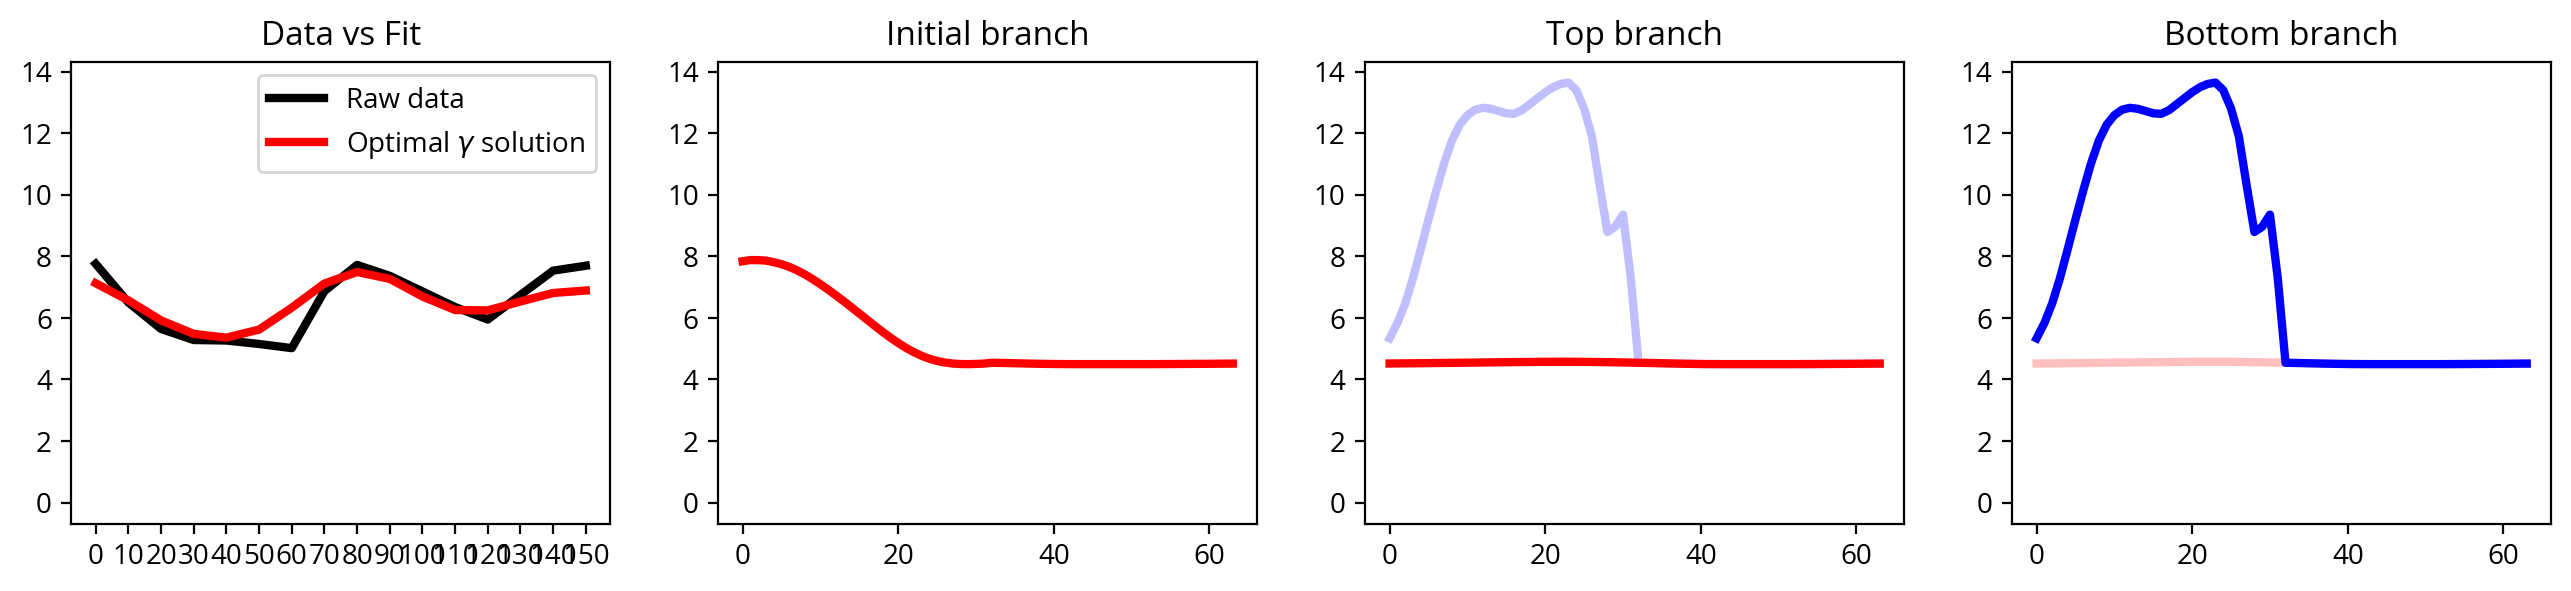

In [598]:
solver.plot_fit()

array([193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
       206, 207, 208,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127,  64,  65,  66,  67,
        68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,
        81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
       107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119,
       120, 121, 122, 123, 124, 125, 126, 127, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176])

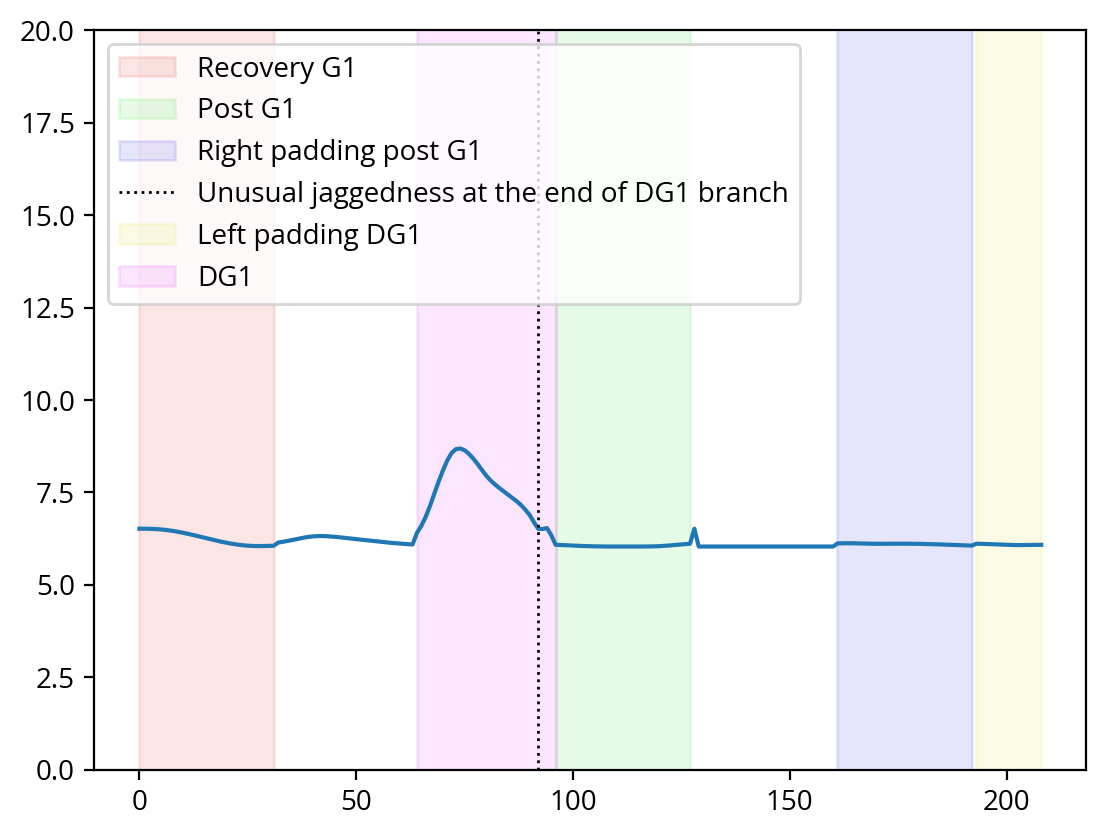

In [583]:

solver = find_gamma.deconvolution_solver

plt.plot(solver.f_padded_variation + solver.f_baseline.value)

plt.axvspan(0, 31, -20, 20, color='#d00', zorder=0, alpha=0.1, label='Recovery G1')
plt.axvspan(96, 127, -20, 20, color='#0d0', zorder=0, alpha=0.1, label="Post G1")
plt.axvspan(161, 192, -20, 20, color='#00d', zorder=0, alpha=0.1, 
            label="Right padding post G1")

plt.axvline(92, lw=1, c='black', ls='dotted', 
    label="Unusual jaggedness at the end of DG1 branch")
plt.ylim(0, 20)
plt.axvspan(193, 208, -20, 20, color='#dd0', zorder=0, alpha=0.1, label="Left padding DG1")
plt.axvspan(64, 96, -20, 20, color='#d0f', zorder=0, alpha=0.1, label="DG1")

plt.legend()

solver.f_bottom_padded_indices
# I am seeing indication of off by one indexing error

In [521]:
solver.f_bottom_padded_indices

array([193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
       206, 207, 208,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127,  64,  65,  66,  67,
        68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,
        81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
       107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119,
       120, 121, 122, 123, 124, 125, 126, 127, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176])

92

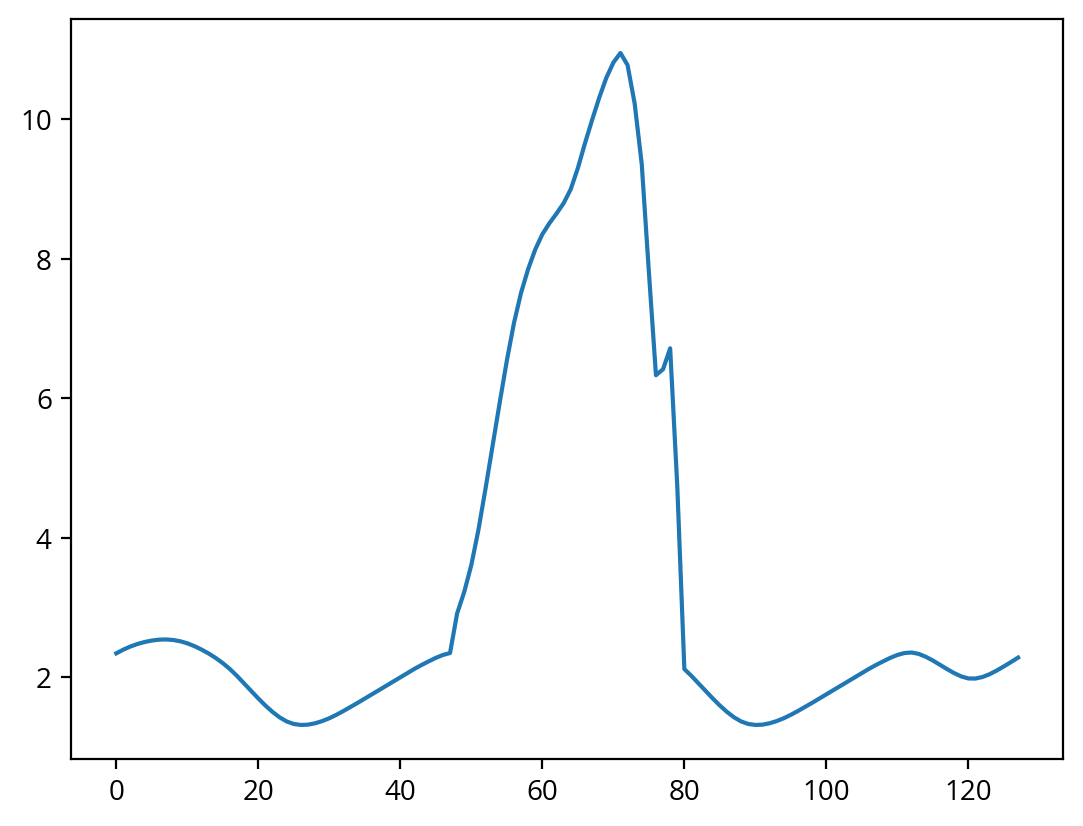

In [391]:
plt.plot(solver.f_padded_variation[solver.f_bottom_padded_indices])
solver.f_bottom_padded_indices[76]

In [347]:
W = solver.W_itb

In [563]:
from src.improved_deconvolution_solver import ImprovedDeconvolutionSolver
from src.config import load_default_chrom_configs

mod_config1, config2 = load_default_chrom_configs()
mod_config1.modify_alpha(32)
mod_config1.g1_num_tps = 22
mod_config1.postg1_num_tps = 42
mod_config1.update_timepoints()
H = mod_config1.calculate_H()


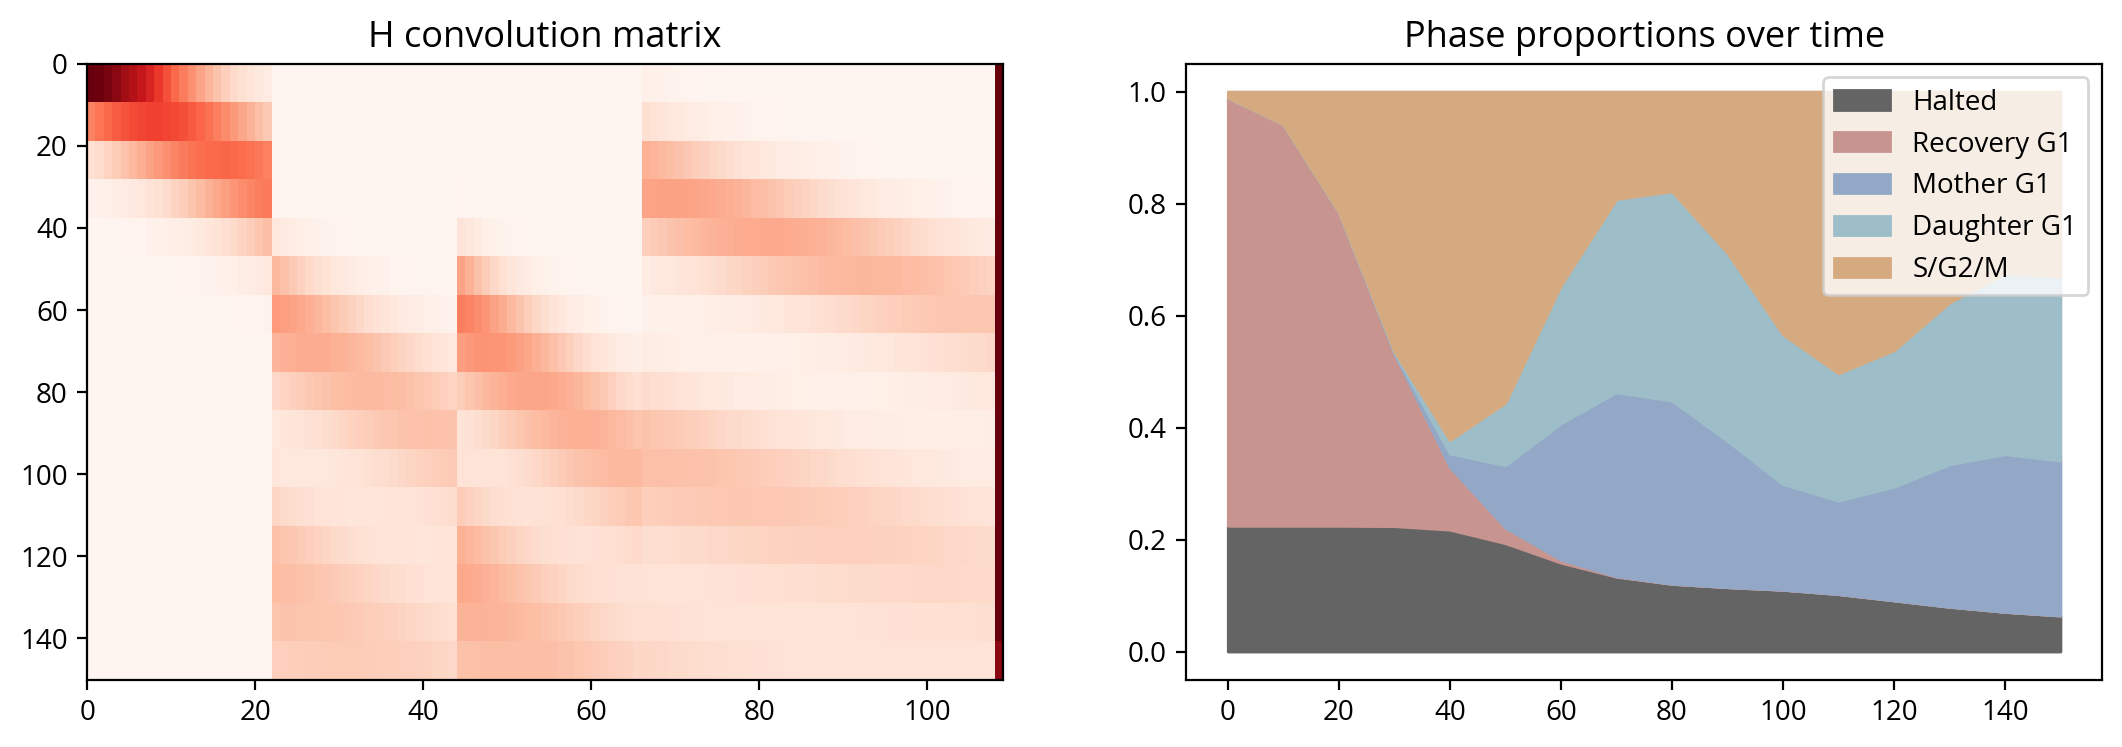

In [564]:
mod_config1.plot_H()

In [576]:
improved_solver = ImprovedDeconvolutionSolver(mod_config1, solver.g, 
    mod_config1.H, gamma=0.001, kappa=0)

In [577]:
f_res = improved_solver.deconvolve()

0

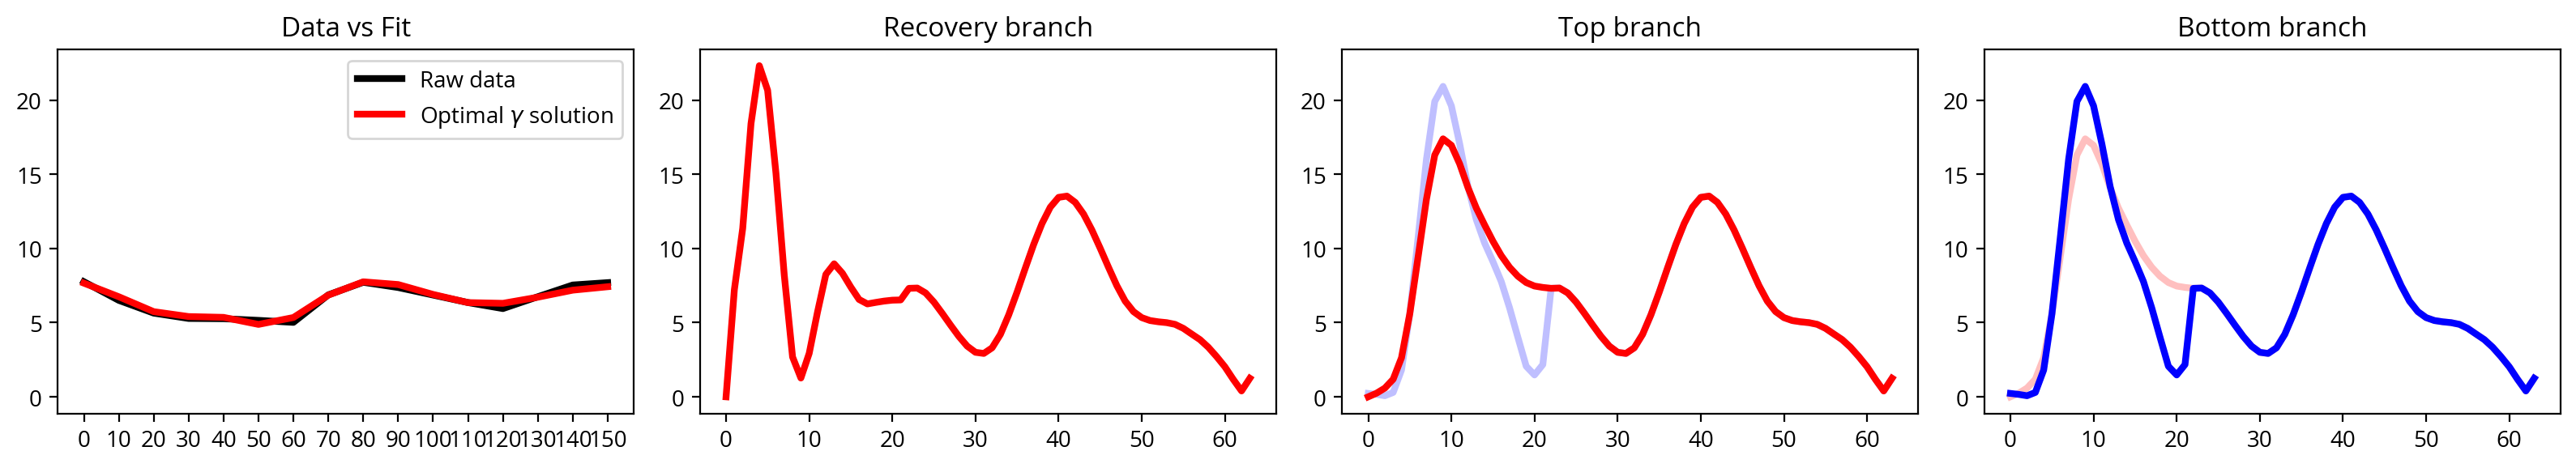

In [578]:
improved_solver.plot_fit()
0

(<Figure size 1200x900 with 3 Axes>,
 array([<Axes: title={'center': 'Recovery Branch Edge Handling'}, xlabel='Position', ylabel='Expression'>,
        <Axes: title={'center': 'Top Branch Edge Handling'}, xlabel='Position', ylabel='Expression'>,
        <Axes: title={'center': 'Bottom Branch Edge Handling'}, xlabel='Position', ylabel='Expression'>],
       dtype=object))

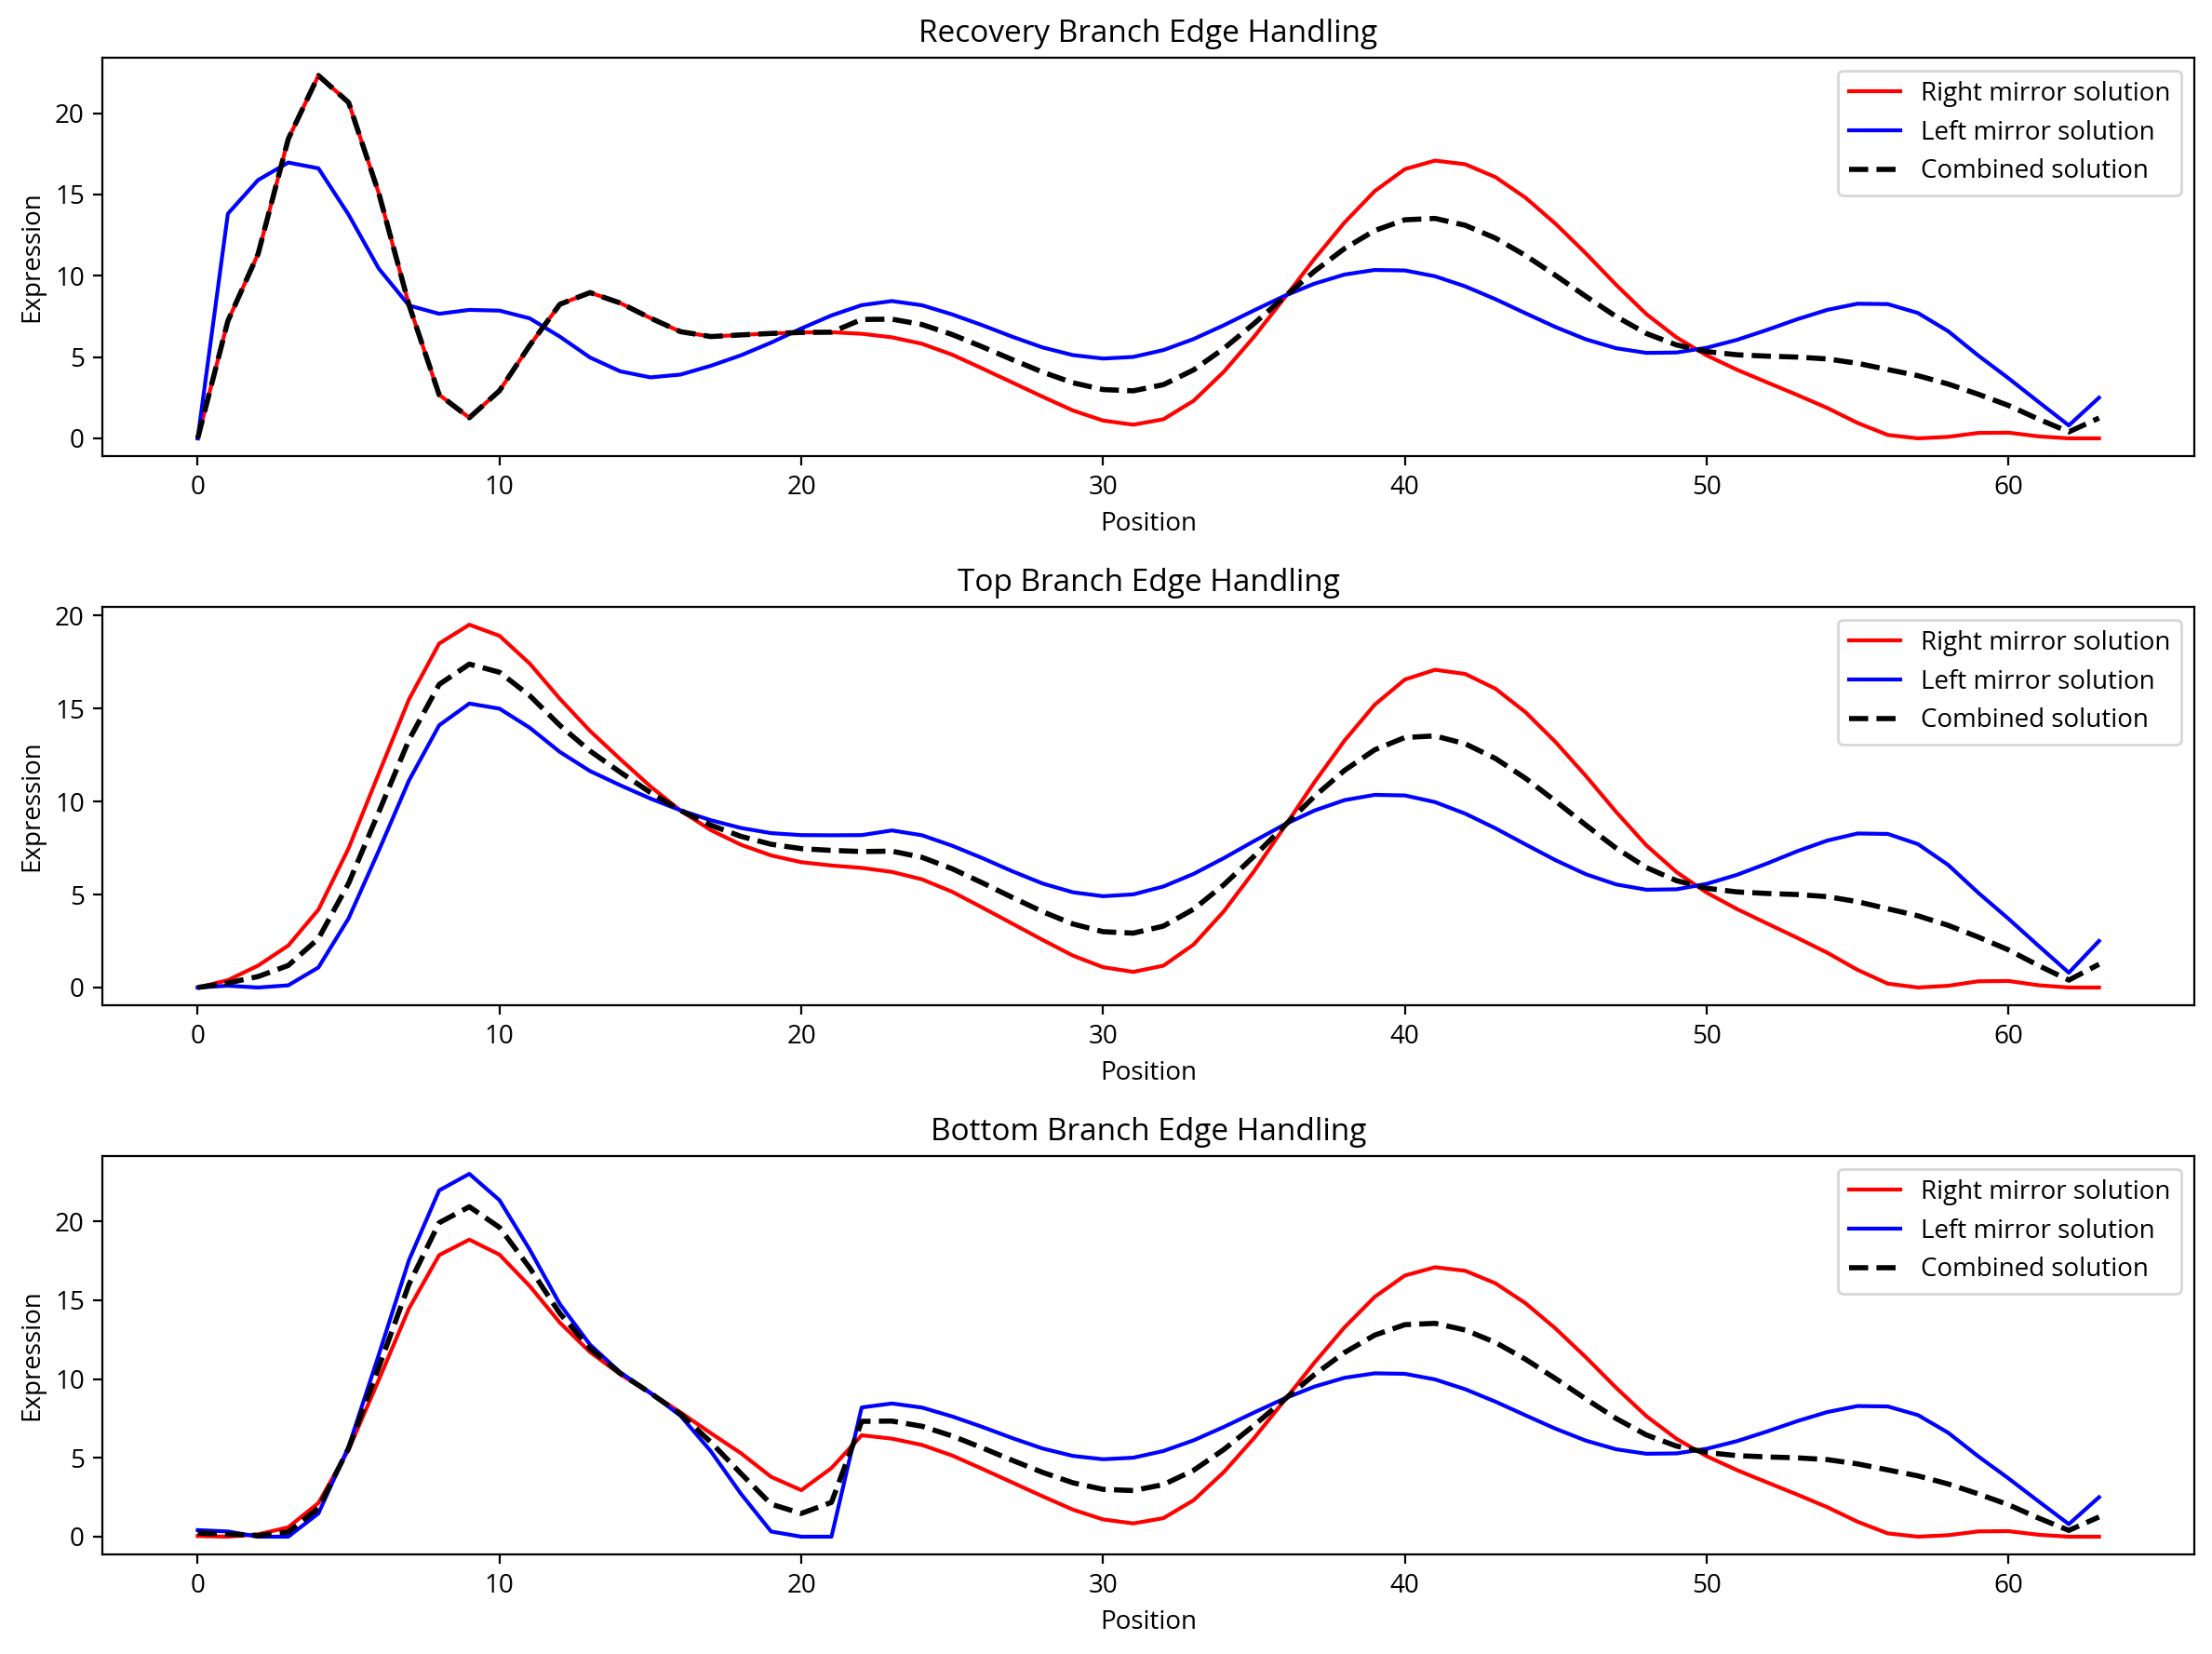

In [579]:
improved_solver.plot_edge_handling_comparison()